# 📚 Library Book Demand Prediction — Model Evaluation
**Seattle Public Library · MDI4001**

A comprehensive backend analysis of all 7 forecasting models. Covers:
- Data exploration & statistics
- Per-model accuracy metrics (MAE, RMSE, MAPE, MdAPE, R², Bias)
- Rolling backtest across 6 months
- Feature importance (Random Forest & Gradient Boosting)
- Forecast distributions & error analysis
- Model correlation heatmap
- Ensemble weighting analysis

In [14]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from src.preprocess import build_monthly_series, complete_monthly_index
from src.models.baselines import seasonal_naive_forecast
from src.models.holt_winters import holt_winters_forecast
from src.models.sarima import sarima_forecast
from src.models.regression import regression_forecast
from src.models.naive_bayes import naive_bayes_forecast
from src.models.random_forest import random_forest_forecast
from src.models.gradient_boost import gradient_boost_forecast

plt.style.use('dark_background')
PALETTE = ['#34D399','#60A5FA','#F59E0B','#F87171','#A78BFA','#EC4899','#10B981']
plt.rcParams.update({'figure.facecolor':'#0A0A0A','axes.facecolor':'#111111',
                     'axes.edgecolor':'#3F3F46','grid.color':'#1C1C20',
                     'text.color':'#E4E4E7','axes.labelcolor':'#A1A1AA',
                     'xtick.color':'#71717A','ytick.color':'#71717A',
                     'font.family':'sans-serif','figure.dpi':110})
print('✓ Imports OK')

✓ Imports OK


## 1 · Load & Preprocess Data

In [15]:
DATA_PATH = 'tmmm-ytt6.csv'
MAX_ROWS  = 200_000
TOP_N     = 40   # titles to forecast
BACKTEST_MONTHS = 6
MODELS = ['naive','holt','regression','sarima','naive_bayes','random_forest','gradient_boost']
MODEL_LABELS = {
    'naive':'Seasonal Naive','holt':'Holt-Winters','regression':'Ridge Regression',
    'sarima':'SARIMA','naive_bayes':'Naive Bayes',
    'random_forest':'Random Forest','gradient_boost':'Gradient Boosting',
}

raw = pd.read_csv(DATA_PATH, nrows=MAX_ROWS)
raw.columns = [c.strip().lower() for c in raw.columns]
print(f'Raw shape: {raw.shape}')
print(f'Columns: {list(raw.columns)}')

Raw shape: (1000, 12)
Columns: ['usageclass', 'checkouttype', 'materialtype', 'checkoutyear', 'checkoutmonth', 'checkouts', 'title', 'isbn', 'creator', 'subjects', 'publisher', 'publicationyear']


In [16]:
monthly = build_monthly_series(raw, only_books=True)
monthly = complete_monthly_index(monthly)

# Filter to top-N most-borrowed titles with ≥6 months history
top_cats = (monthly.groupby('category')['count'].sum()
            .nlargest(TOP_N).index.tolist())
monthly = monthly[monthly['category'].isin(top_cats)].copy()
# Keep only titles with ≥6 months
keep = monthly.groupby('category')['month'].nunique()
keep = keep[keep >= 6].index
monthly = monthly[monthly['category'].isin(keep)].copy()

n_titles = monthly['category'].nunique()
n_months = monthly['month'].nunique()
date_range = f"{monthly['month'].min().strftime('%b %Y')} – {monthly['month'].max().strftime('%b %Y')}"
print(f'Titles: {n_titles} | Months: {n_months} | Range: {date_range}')
monthly.head()

Titles: 1 | Months: 96 | Range: Oct 2016 – Sep 2024


,month,category,count
0,2016-10-01,Physical,1363
1,2016-11-01,Physical,0
2,2016-12-01,Physical,0
3,2017-01-01,Physical,0
4,2017-02-01,Physical,0


## 2 · Dataset Exploration

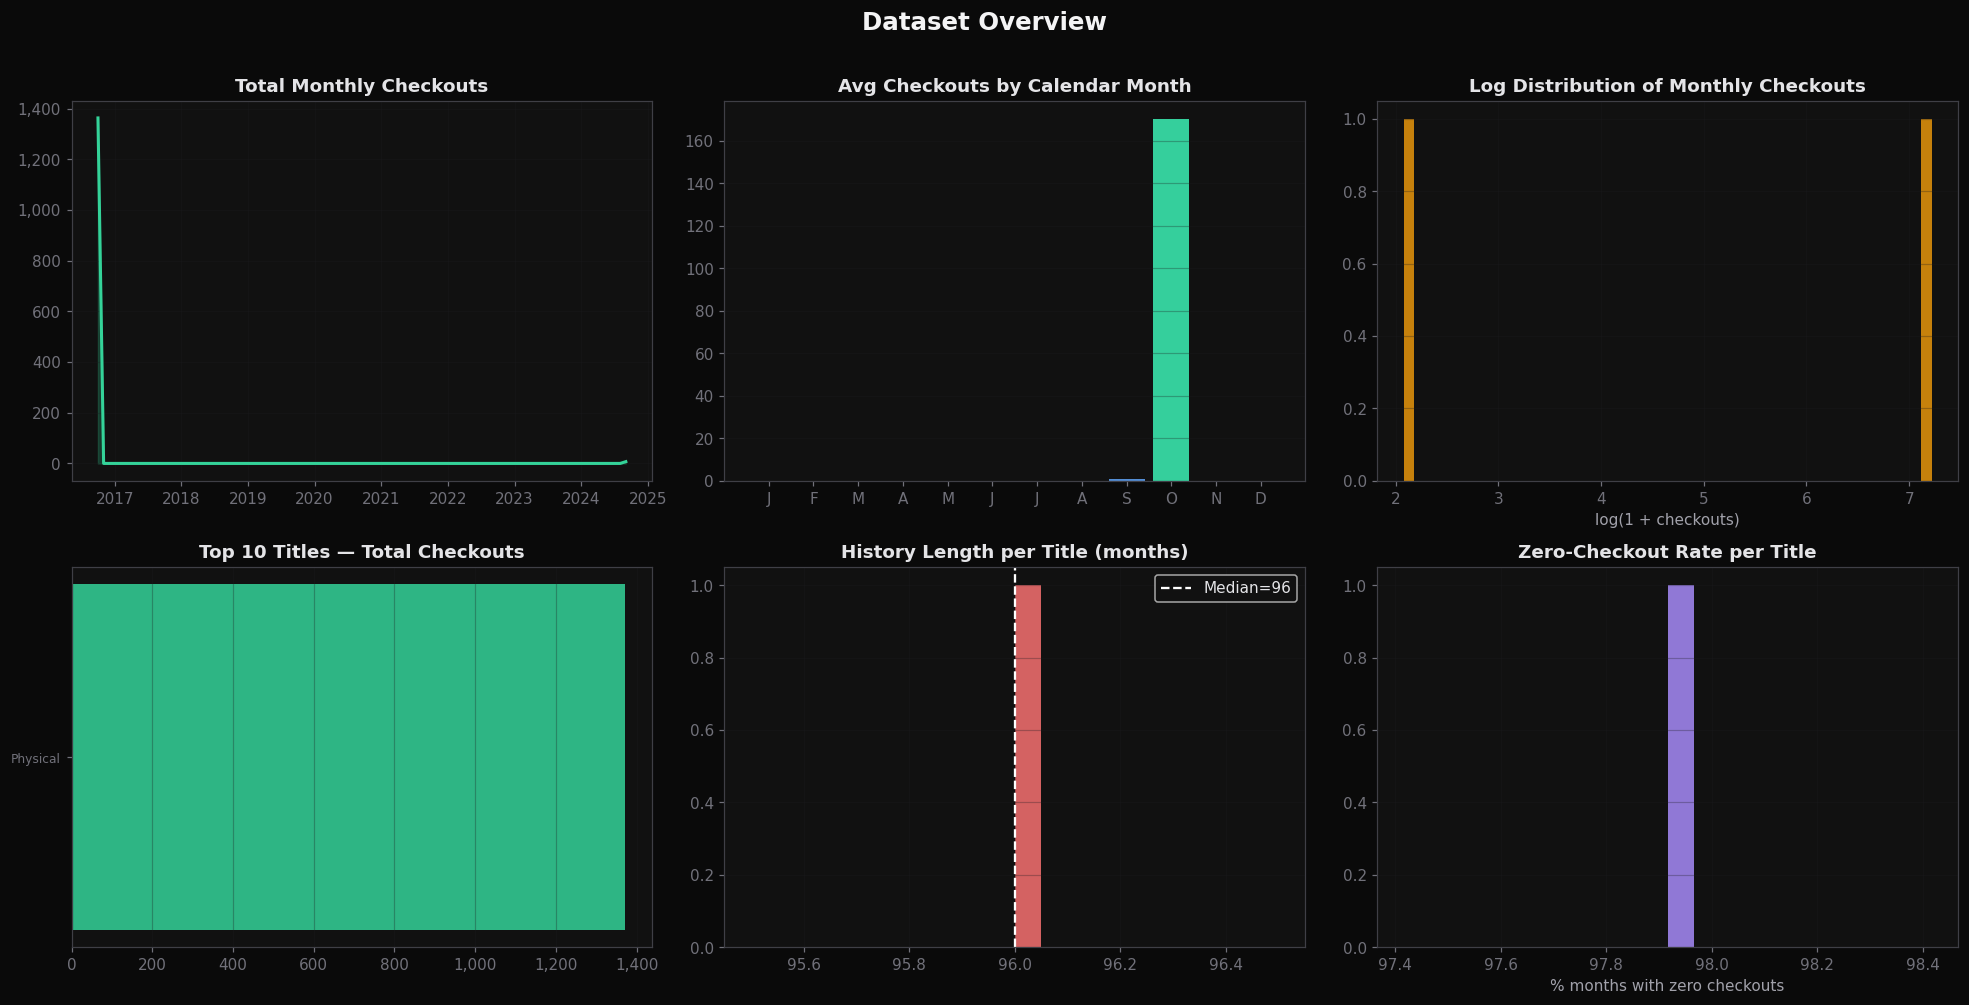


── Dataset Summary ──
Total records (monthly title-month pairs): 96
Unique titles: 1
Months covered: 96 (Oct 2016 – Sep 2024)
Total checkouts: 1,370
Mean checkouts/title/month: 14.27
Median: 0.0  |  Std: 139.10
Max single month: 1,363  |  Sparsity: 97.9%


In [17]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
fig.suptitle('Dataset Overview', fontsize=16, fontweight='bold', color='#F4F4F5', y=1.01)

# 1 – Total monthly checkouts
ax = axes[0,0]
trend = monthly.groupby('month')['count'].sum()
ax.fill_between(trend.index, trend.values, alpha=0.2, color=PALETTE[0])
ax.plot(trend.index, trend.values, color=PALETTE[0], lw=2)
ax.set_title('Total Monthly Checkouts', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(True, alpha=0.3)

# 2 – Seasonality (avg by calendar month)
ax = axes[0,1]
monthly['cal_month'] = monthly['month'].dt.month
seas = monthly.groupby('cal_month')['count'].mean()
bars = ax.bar(seas.index, seas.values, color=PALETTE[1], alpha=0.85, edgecolor='none')
ax.bar(seas.idxmax(), seas.max(), color=PALETTE[0], alpha=0.95, edgecolor='none')
ax.set_xticks(range(1,13))
ax.set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
ax.set_title('Avg Checkouts by Calendar Month', fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# 3 – Checkout distribution (log)
ax = axes[0,2]
nonzero = monthly[monthly['count'] > 0]['count']
ax.hist(np.log1p(nonzero), bins=50, color=PALETTE[2], alpha=0.8, edgecolor='none')
ax.set_title('Log Distribution of Monthly Checkouts', fontweight='bold')
ax.set_xlabel('log(1 + checkouts)')
ax.grid(True, alpha=0.3)

# 4 – Top-10 titles by total demand
ax = axes[1,0]
top10 = monthly.groupby('category')['count'].sum().nlargest(10)
y_pos = range(len(top10))
bars = ax.barh(y_pos, top10.values, color=PALETTE[0], alpha=0.85)
ax.set_yticks(y_pos)
ax.set_yticklabels([t[:35] for t in top10.index], fontsize=8)
ax.set_title('Top 10 Titles — Total Checkouts', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
ax.grid(True, alpha=0.3, axis='x')

# 5 – History length distribution
ax = axes[1,1]
hist_len = monthly.groupby('category')['month'].nunique()
ax.hist(hist_len.values, bins=20, color=PALETTE[3], alpha=0.85, edgecolor='none')
ax.axvline(hist_len.median(), color='white', ls='--', lw=1.5, label=f'Median={hist_len.median():.0f}')
ax.set_title('History Length per Title (months)', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

# 6 – Zero-checkout rate per title
ax = axes[1,2]
zero_rate = monthly.groupby('category').apply(lambda g: (g['count']==0).mean())
ax.hist(zero_rate.values * 100, bins=20, color=PALETTE[4], alpha=0.85, edgecolor='none')
ax.set_xlabel('% months with zero checkouts')
ax.set_title('Zero-Checkout Rate per Title', fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary stats
print('\n── Dataset Summary ──')
print(f'Total records (monthly title-month pairs): {len(monthly):,}')
print(f'Unique titles: {n_titles}')
print(f'Months covered: {n_months} ({date_range})')
print(f'Total checkouts: {monthly["count"].sum():,.0f}')
print(f'Mean checkouts/title/month: {monthly["count"].mean():.2f}')
print(f'Median: {monthly["count"].median():.1f}  |  Std: {monthly["count"].std():.2f}')
print(f'Max single month: {monthly["count"].max():,.0f}  |  Sparsity: {(monthly["count"]==0).mean()*100:.1f}%')

## 3 · Rolling Backtest — All Models

In [18]:
def run_model(name, train):
    fn = dict(naive=seasonal_naive_forecast, holt=holt_winters_forecast,
               sarima=sarima_forecast, regression=regression_forecast,
               naive_bayes=naive_bayes_forecast, random_forest=random_forest_forecast,
               gradient_boost=gradient_boost_forecast)[name]
    return fn(train)

unique_months = sorted(monthly['month'].unique())
eval_months   = unique_months[-BACKTEST_MONTHS:]

all_rows = []
for model_name in MODELS:
    print(f'  Backtesting {MODEL_LABELS[model_name]}...', end=' ', flush=True)
    for eval_month in eval_months:
        train  = monthly[monthly['month'] < eval_month]
        actual = monthly[monthly['month'] == eval_month][['category','count']].rename(columns={'count':'actual'})
        if train.empty or actual.empty:
            continue
        try:
            preds = run_model(model_name, train)
        except Exception as e:
            continue
        merged = actual.merge(preds[['category','predicted']], on='category', how='inner')
        merged['predicted'] = merged['predicted'].clip(lower=0)
        merged['model'] = model_name
        merged['eval_month'] = eval_month
        all_rows.append(merged)
    print('done')

bt = pd.concat(all_rows, ignore_index=True)
bt['error']    = bt['predicted'] - bt['actual']
bt['abs_error']= bt['error'].abs()
bt['denom']    = np.maximum(bt['actual'], 1)
bt['ape']      = bt['abs_error'] / bt['denom']   # absolute percentage error
print(f'\nBacktest rows: {len(bt):,}')
bt.head()

  Backtesting Seasonal Naive... done
  Backtesting Holt-Winters... done
  Backtesting Ridge Regression... done
  Backtesting SARIMA... done
  Backtesting Naive Bayes... done
  Backtesting Random Forest... done
  Backtesting Gradient Boosting... done

Backtest rows: 42


,category,actual,predicted,model,eval_month,error,abs_error,denom,ape
0,Physical,0,0.0,naive,2024-04-01,0.0,0.0,1,0.0
1,Physical,0,0.0,naive,2024-05-01,0.0,0.0,1,0.0
2,Physical,0,0.0,naive,2024-06-01,0.0,0.0,1,0.0
3,Physical,0,0.0,naive,2024-07-01,0.0,0.0,1,0.0
4,Physical,0,0.0,naive,2024-08-01,0.0,0.0,1,0.0


## 4 · Aggregate Metrics per Model

In [19]:
def compute_metrics(df):
    n = len(df)
    mae   = df['abs_error'].mean()
    rmse  = np.sqrt((df['error']**2).mean())
    mape  = df['ape'].mean() * 100
    mdape = df['ape'].median() * 100
    bias  = df['error'].mean()
    corr  = df[['actual','predicted']].corr().iloc[0,1]
    ss_res= (df['error']**2).sum()
    ss_tot= ((df['actual'] - df['actual'].mean())**2).sum()
    r2    = 1 - ss_res/ss_tot if ss_tot > 0 else float('nan')
    # Within-X% hit rate
    hit20 = (df['ape'] <= 0.20).mean() * 100
    hit50 = (df['ape'] <= 0.50).mean() * 100
    return dict(MAE=mae, RMSE=rmse, MAPE_pct=mape, MdAPE_pct=mdape,
                Bias=bias, R2=r2, Corr=corr,
                Hit20pct=hit20, Hit50pct=hit50, N=n)

rows = []
for m in MODELS:
    d = bt[bt['model'] == m]
    if d.empty:
        continue
    row = compute_metrics(d)
    row['Model'] = MODEL_LABELS[m]
    rows.append(row)

summary = pd.DataFrame(rows).set_index('Model')
summary = summary.sort_values('MAPE_pct')
summary_display = summary[['MAE','RMSE','MAPE_pct','MdAPE_pct','Bias','R2','Corr','Hit20pct','Hit50pct','N']].copy()
summary_display.columns = ['MAE','RMSE','MAPE %','MdAPE %','Bias','R²','Corr','Hit≤20%','Hit≤50%','N']
summary_display.style.format({
    'MAE':'{:.1f}','RMSE':'{:.1f}','MAPE %':'{:.1f}','MdAPE %':'{:.1f}',
    'Bias':'{:.2f}','R²':'{:.3f}','Corr':'{:.3f}','Hit≤20%':'{:.1f}','Hit≤50%':'{:.1f}','N':'{:,}'
}).background_gradient(cmap='YlGn', subset=['Hit≤20%','Hit≤50%','R²','Corr'])\
  .background_gradient(cmap='YlOrRd_r', subset=['MAPE %','MAE','RMSE'])

,MAE,RMSE,MAPE %,MdAPE %,Bias,R²,Corr,Hit≤20%,Hit≤50%,N
Model,,,,,,,,,,
Seasonal Naive,1.2,2.9,16.7,0.0,-1.17,-0.200,nan,83.3,83.3,6
Holt-Winters,1.2,2.9,16.7,0.0,-1.17,-0.200,nan,83.3,83.3,6
Ridge Regression,1.2,2.9,16.7,0.0,-1.17,-0.200,nan,83.3,83.3,6
Naive Bayes,1.2,2.9,16.7,0.0,-1.17,-0.200,nan,83.3,83.3,6
Random Forest,1.2,2.9,16.7,0.0,-1.17,-0.200,nan,83.3,83.3,6
Gradient Boosting,1.2,2.9,16.7,0.0,-1.17,-0.200,nan,83.3,83.3,6
SARIMA,1.2,2.9,16.7,0.0,-1.17,-0.200,-0.200,83.3,83.3,6


In [20]:
print('══ Model Performance Summary ══')
print(summary_display.to_string())
best = summary['MAPE_pct'].idxmin()
print(f'\n🏆 Best model by MAPE: {best} ({summary.loc[best,"MAPE_pct"]:.1f}%)')

══ Model Performance Summary ══
                        MAE      RMSE     MAPE %       MdAPE %      Bias   R²      Corr    Hit≤20%    Hit≤50%  N
Model                                                                                                           
Seasonal Naive     1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Holt-Winters       1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Ridge Regression   1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Naive Bayes        1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Random Forest      1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Gradient Boosting  1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
SARIMA             1.166672  2.857738  16.667161  8.178708e-09 -

## 5 · Visual Comparison of Metrics

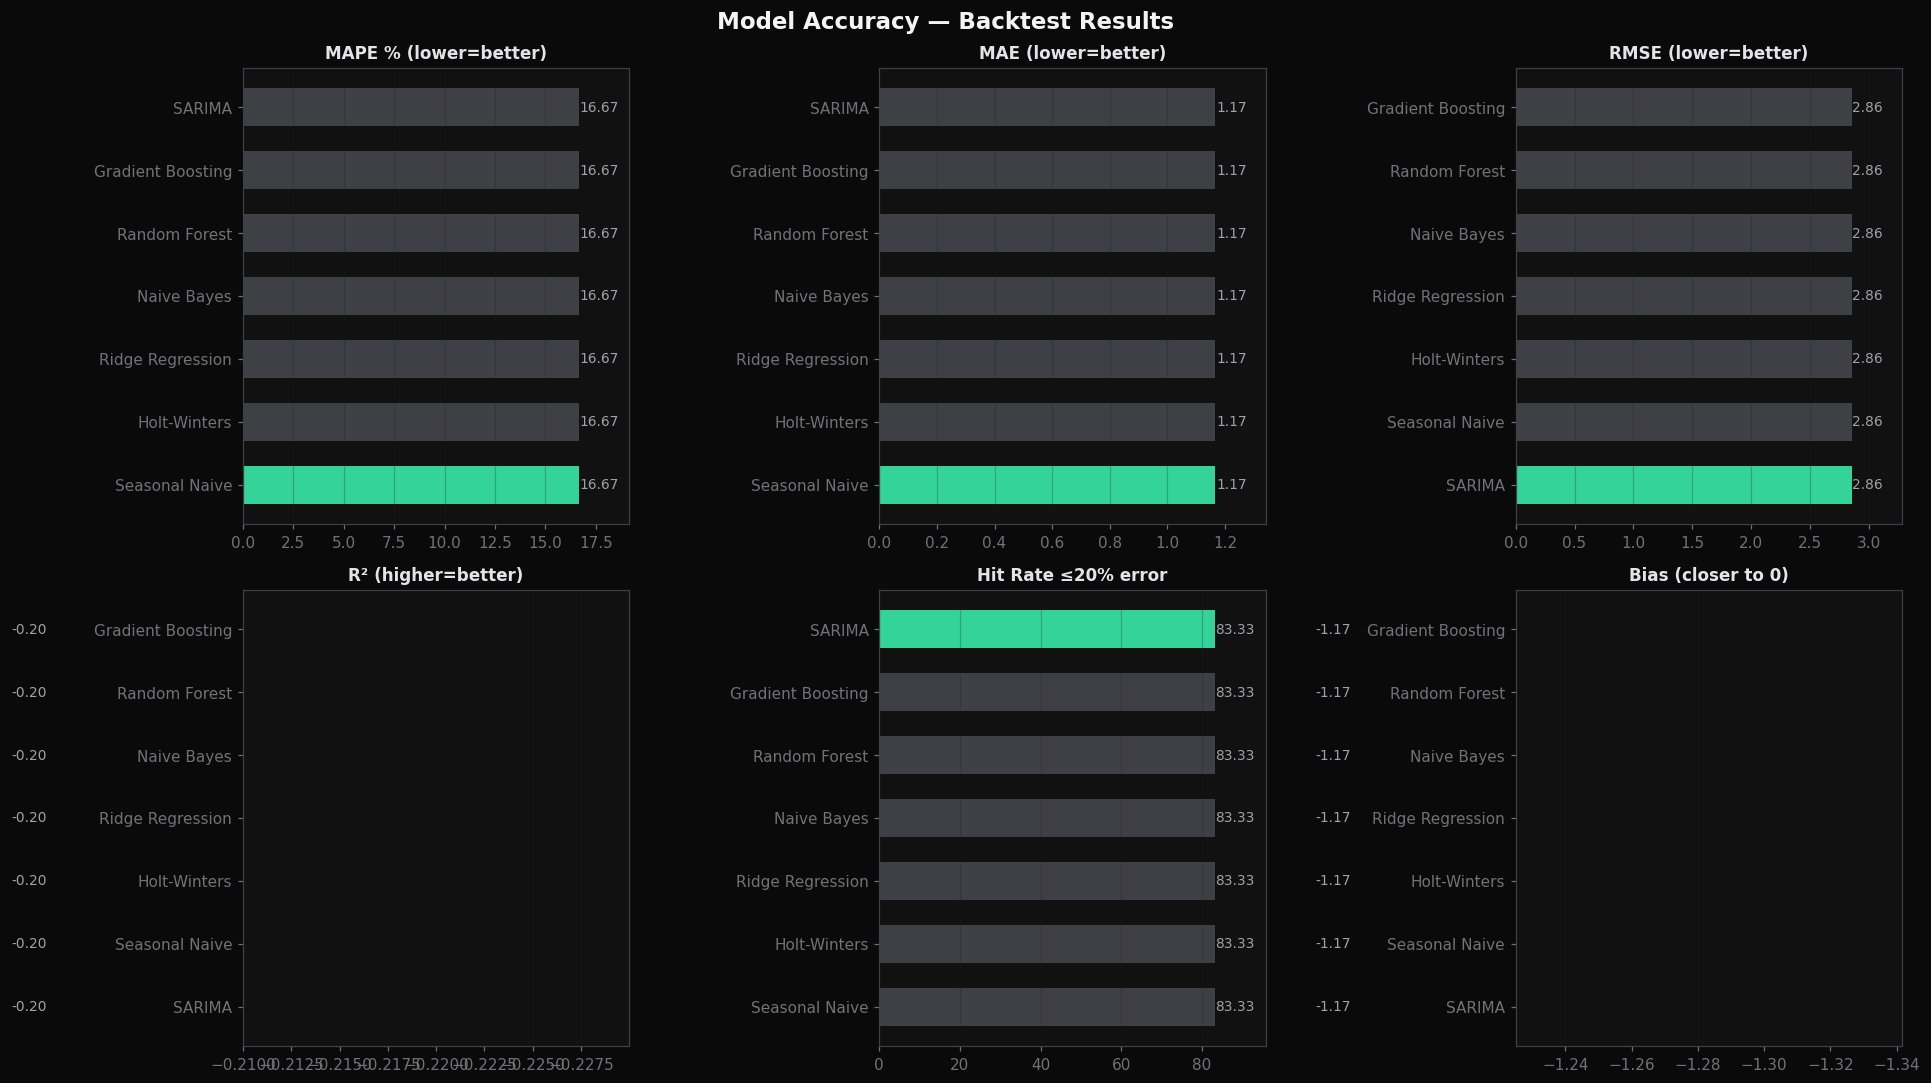

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Model Accuracy — Backtest Results', fontsize=15, fontweight='bold', color='#F4F4F5')

metrics_plot = [
    ('MAPE_pct','MAPE % (lower=better)', True),
    ('MAE',     'MAE (lower=better)',    True),
    ('RMSE',    'RMSE (lower=better)',   True),
    ('R2',      'R² (higher=better)',    False),
    ('Hit20pct','Hit Rate ≤20% error',   False),
    ('Bias',    'Bias (closer to 0)',    None),
]

for ax, (col, title, lower_better) in zip(axes.flat, metrics_plot):
    vals = summary[col].sort_values(ascending=(lower_better if lower_better is not None else False))
    colors = [PALETTE[0] if i == (0 if lower_better else len(vals)-1) else '#3F3F46'
              for i in range(len(vals))]
    if lower_better is None:  # Bias — colour by sign
        colors = [PALETTE[0] if abs(v) == min(abs(vals)) else ('#60A5FA' if v >= 0 else '#F87171')
                  for v in vals]
    bars = ax.barh(vals.index, vals.values, color=colors, height=0.6, edgecolor='none')
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.grid(True, alpha=0.25, axis='x')
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=9, color='#A1A1AA')
    ax.set_xlim(right=vals.max() * 1.15)

plt.tight_layout()
plt.show()

## 6 · Error Distribution per Model

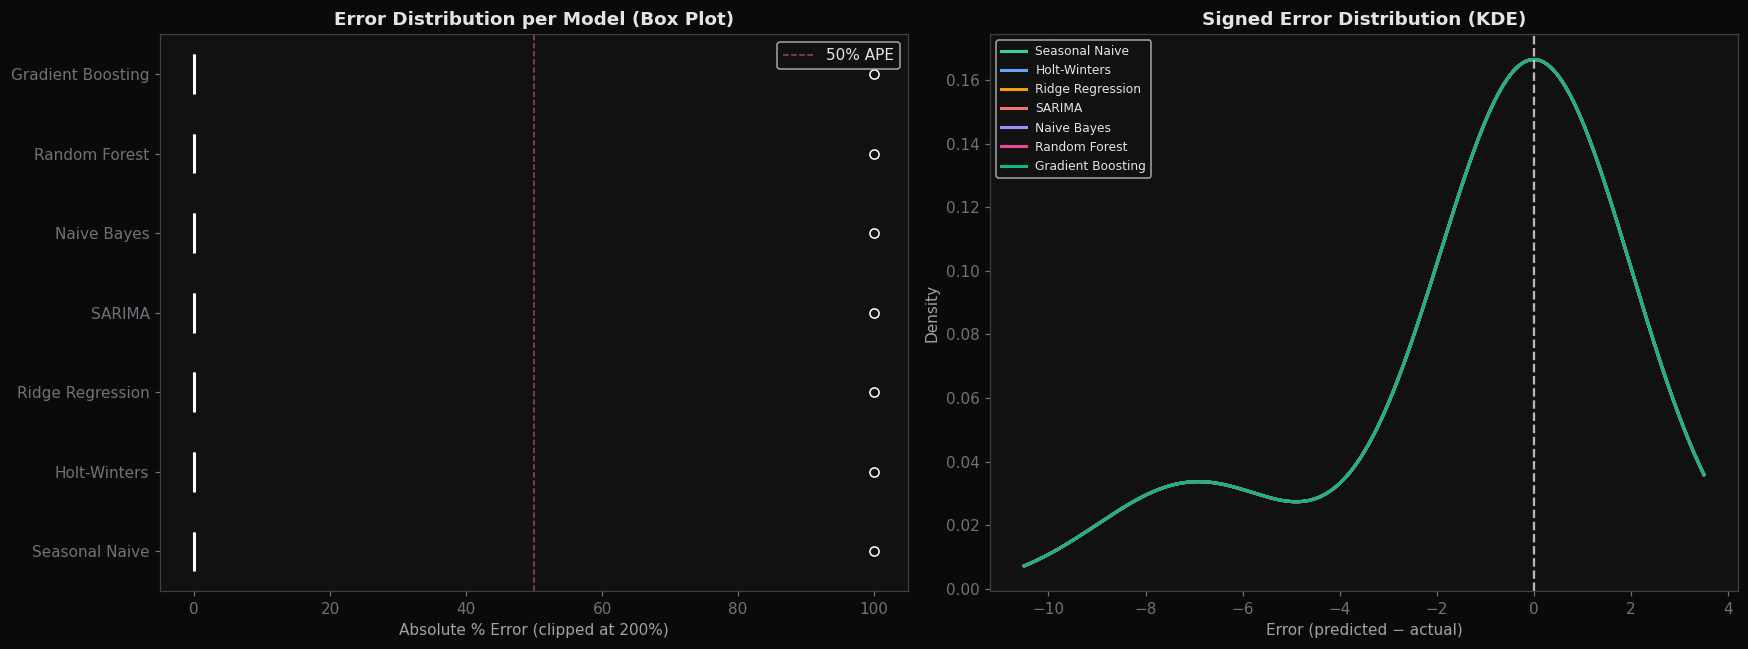

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of APE per model
ax = axes[0]
model_order = summary.sort_values('MAPE_pct').index
ape_data = [bt[bt['model'] == m]['ape'].clip(upper=2).values * 100
            for m in MODELS if MODEL_LABELS[m] in model_order]
ape_labels = [MODEL_LABELS[m] for m in MODELS if MODEL_LABELS[m] in model_order]
bp = ax.boxplot(ape_data, vert=False, patch_artist=True, labels=ape_labels,
                medianprops=dict(color='white',lw=2))
for patch, color in zip(bp['boxes'], PALETTE):
    patch.set_facecolor(color); patch.set_alpha(0.6)
ax.set_xlabel('Absolute % Error (clipped at 200%)')
ax.set_title('Error Distribution per Model (Box Plot)', fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.axvline(50, color='#F87171', ls='--', lw=1, alpha=0.6, label='50% APE')
ax.legend()

# KDE of signed errors
ax = axes[1]
for i, m in enumerate(MODELS):
    errs = bt[bt['model'] == m]['error'].clip(-200, 200)
    if len(errs) > 5:
        errs.plot.kde(ax=ax, label=MODEL_LABELS[m], color=PALETTE[i % len(PALETTE)], lw=2)
ax.axvline(0, color='white', ls='--', lw=1.5, alpha=0.7)
ax.set_xlabel('Error (predicted − actual)')
ax.set_title('Signed Error Distribution (KDE)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7 · Predicted vs Actual Scatter

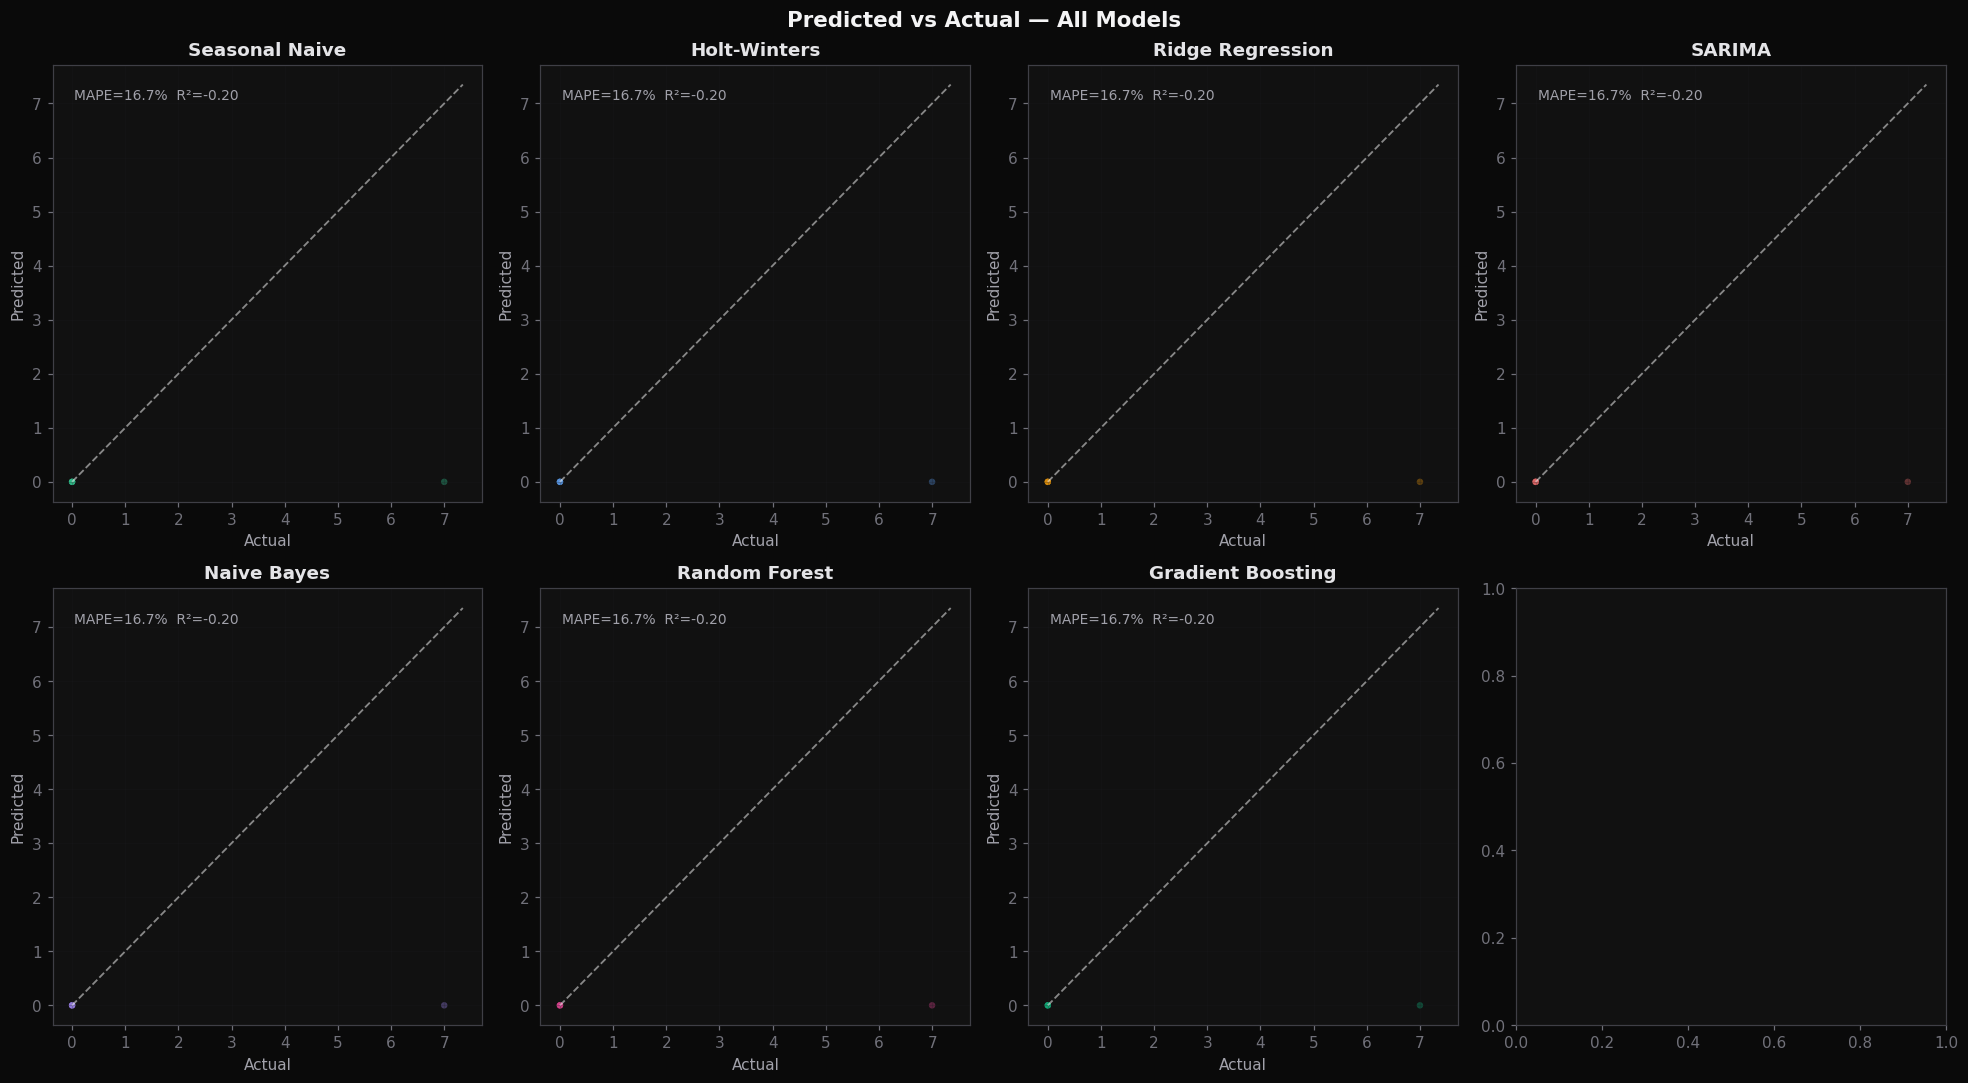

In [23]:
n_models = len(MODELS)
ncols = 4
nrows = (n_models + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flat

for ax, m in zip(axes, MODELS):
    d = bt[bt['model'] == m].copy()
    ax.scatter(d['actual'], d['predicted'], alpha=0.35, s=18,
               color=PALETTE[MODELS.index(m) % len(PALETTE)], edgecolors='none')
    lim = max(d['actual'].max(), d['predicted'].max()) * 1.05
    ax.plot([0, lim], [0, lim], '--', color='white', lw=1.2, alpha=0.5)
    ax.set_title(MODEL_LABELS[m], fontweight='bold')
    ax.set_xlabel('Actual'); ax.set_ylabel('Predicted')
    mape = d['ape'].mean() * 100
    r2 = summary.loc[MODEL_LABELS[m],'R2'] if MODEL_LABELS[m] in summary.index else float('nan')
    ax.text(0.05, 0.92, f'MAPE={mape:.1f}%  R²={r2:.2f}',
            transform=ax.transAxes, fontsize=9, color='#A1A1AA')
    ax.grid(True, alpha=0.25)

for ax in list(axes)[n_models:]:
    ax.set_visible(False)

plt.suptitle('Predicted vs Actual — All Models', fontsize=14, fontweight='bold', color='#F4F4F5')
plt.tight_layout()
plt.show()

## 8 · Per-Month Backtest Accuracy

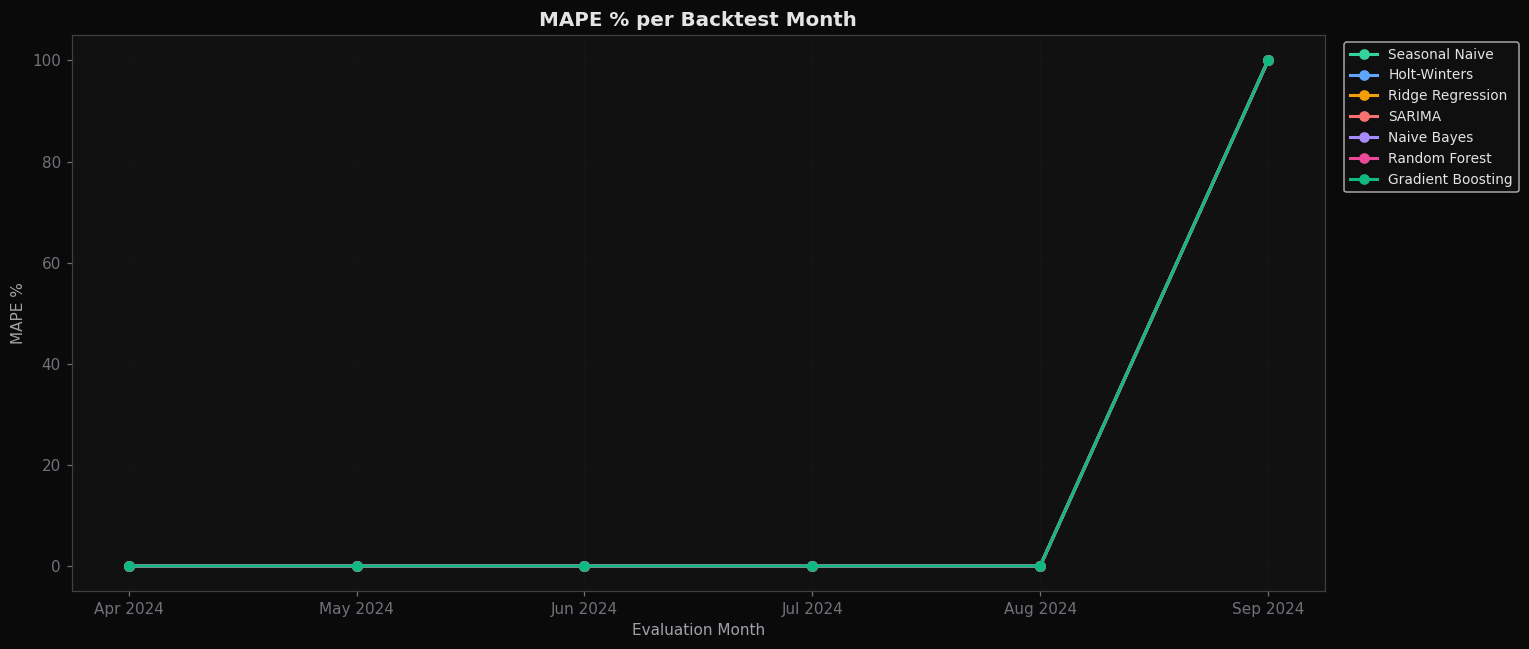

In [24]:
monthly_mape = (
    bt.groupby(['model','eval_month'])['ape']
    .mean().reset_index()
)
monthly_mape['MAPE %'] = monthly_mape['ape'] * 100
monthly_mape['month_str'] = pd.to_datetime(monthly_mape['eval_month']).dt.strftime('%b %Y')

fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(MODELS):
    d = monthly_mape[monthly_mape['model'] == m].sort_values('eval_month')
    ax.plot(d['month_str'], d['MAPE %'], marker='o', lw=2,
            label=MODEL_LABELS[m], color=PALETTE[i % len(PALETTE)])

ax.set_title('MAPE % per Backtest Month', fontweight='bold', fontsize=13)
ax.set_xlabel('Evaluation Month')
ax.set_ylabel('MAPE %')
ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9 · Model Correlation (Forecast Agreement)

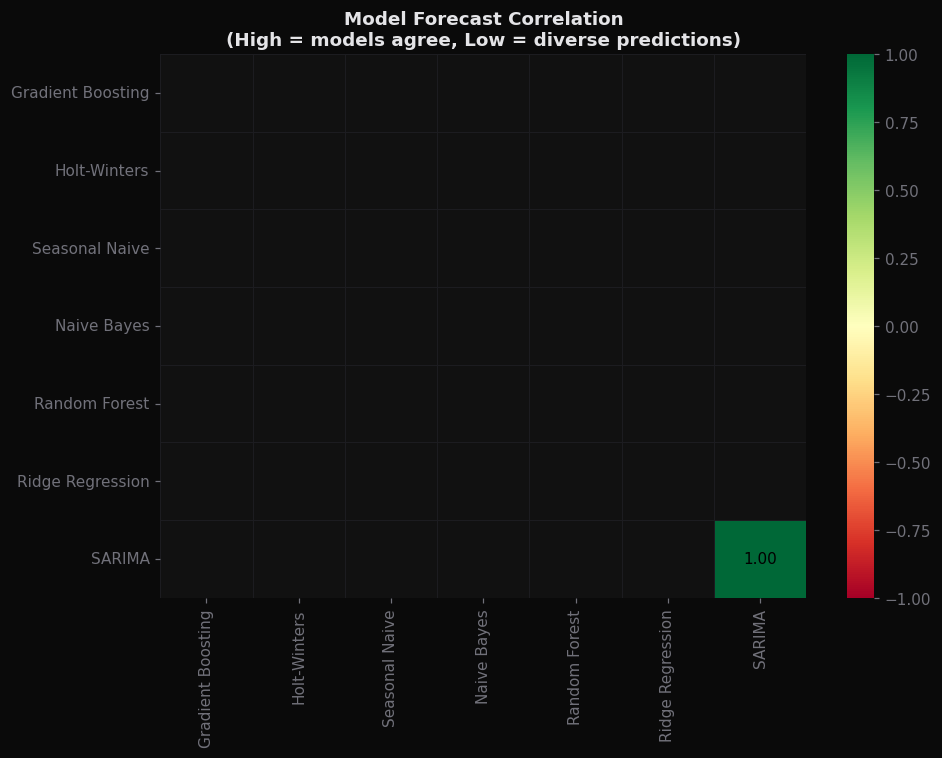

In [25]:
# Pivot to get one column per model, one row per (category, eval_month)
pred_wide = bt.pivot_table(
    index=['category','eval_month'], columns='model', values='predicted'
).dropna()

corr = pred_wide.corr()
corr.index   = [MODEL_LABELS.get(c, c) for c in corr.index]
corr.columns = [MODEL_LABELS.get(c, c) for c in corr.columns]

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=-1, vmax=1, center=0, ax=ax,
            linewidths=0.5, linecolor='#1C1C20',
            annot_kws={'size':10, 'color':'black'})
ax.set_title('Model Forecast Correlation\n(High = models agree, Low = diverse predictions)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## 10 · Feature Importance — Random Forest & Gradient Boosting

AttributeError: 'HistGradientBoostingRegressor' object has no attribute 'feature_importances_'

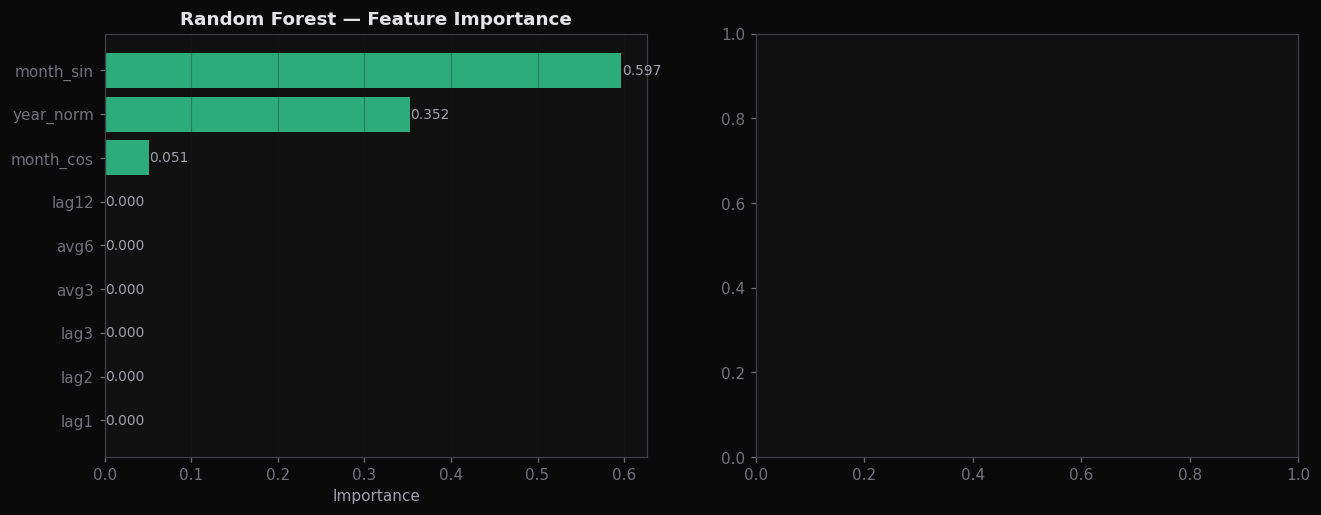

In [26]:
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
import numpy as np

FEAT_COLS = ['month_sin','month_cos','year_norm','lag1','lag2','lag3','avg3','avg6','lag12']

def build_feats(group):
    d = group.sort_values('month').copy()
    m = d['month'].dt.month
    d['month_sin'] = np.sin(2*np.pi*m/12)
    d['month_cos'] = np.cos(2*np.pi*m/12)
    d['year_norm'] = d['month'].dt.year - 2010
    d['lag1']  = d['count'].shift(1)
    d['lag2']  = d['count'].shift(2)
    d['lag3']  = d['count'].shift(3)
    d['avg3']  = d['count'].shift(1).rolling(3).mean()
    d['avg6']  = d['count'].shift(1).rolling(6).mean()
    d['lag12'] = d['count'].shift(12).fillna(0)
    return d

frames = [build_feats(g) for _, g in monthly.groupby('category')]
full = pd.concat(frames)
core = ['month_sin','month_cos','year_norm','lag1','lag2','lag3','avg3','avg6']
full = full.dropna(subset=core+['count'])
full['lag12'] = full['lag12'].fillna(0)

X, y = full[FEAT_COLS], full['count']

rf = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=3,
                            random_state=42, n_jobs=-1)
rf.fit(X, y)

hgb = HistGradientBoostingRegressor(max_iter=400, learning_rate=0.05,
                                     max_depth=6, min_samples_leaf=10, random_state=42)
hgb.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, name, color in [
    (axes[0], rf,  'Random Forest',       PALETTE[0]),
    (axes[1], hgb, 'Gradient Boosting',   PALETTE[1]),
]:
    imp = pd.Series(model.feature_importances_, index=FEAT_COLS).sort_values()
    bars = ax.barh(imp.index, imp.values, color=color, alpha=0.8, edgecolor='none')
    ax.set_title(f'{name} — Feature Importance', fontweight='bold')
    ax.set_xlabel('Importance')
    ax.grid(True, alpha=0.3, axis='x')
    for bar, val in zip(bars, imp.values):
        ax.text(bar.get_width() + 0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9, color='#A1A1AA')

plt.suptitle('Feature Importance — ML Models', fontsize=13, fontweight='bold', color='#F4F4F5')
plt.tight_layout()
plt.show()

## 11 · Ensemble Weights (Inverse-MAPE)

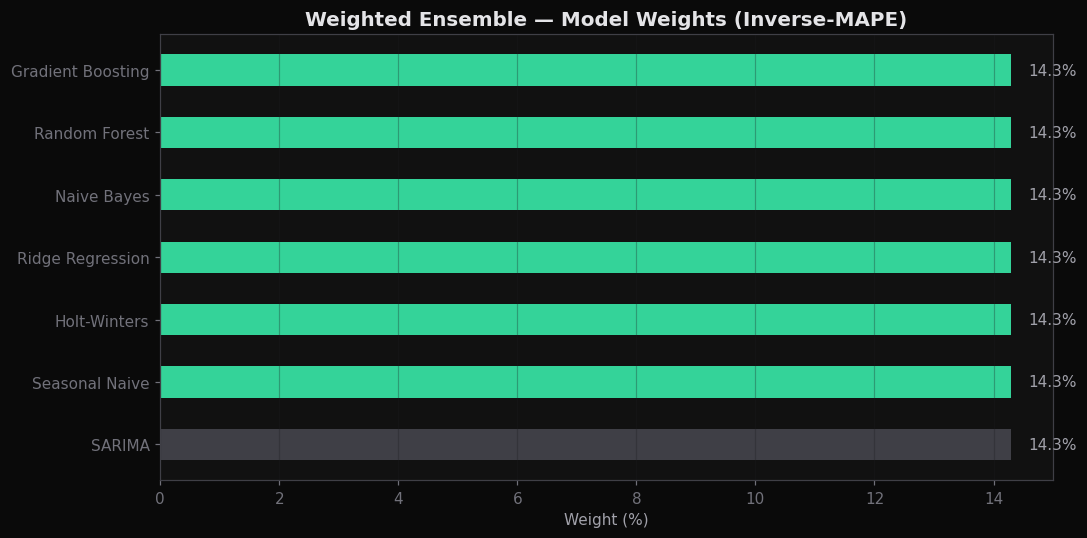

── Ensemble Weights ──
  Seasonal Naive             14.3%  (MAPE=16.7%)
  Holt-Winters               14.3%  (MAPE=16.7%)
  Ridge Regression           14.3%  (MAPE=16.7%)
  Naive Bayes                14.3%  (MAPE=16.7%)
  Random Forest              14.3%  (MAPE=16.7%)
  Gradient Boosting          14.3%  (MAPE=16.7%)
  SARIMA                     14.3%  (MAPE=16.7%)


In [27]:
mapes = {m: bt[bt['model']==m]['ape'].mean() for m in MODELS if not bt[bt['model']==m].empty}
raw_w = {m: 1.0/max(v, 1e-4) for m,v in mapes.items()}
total = sum(raw_w.values())
weights = {m: w/total for m,w in raw_w.items()}

fig, ax = plt.subplots(figsize=(10, 5))
w_series = pd.Series({MODEL_LABELS[m]: v for m,v in weights.items()}).sort_values(ascending=True)
colors_w = [PALETTE[0] if v == w_series.max() else '#3F3F46' for v in w_series]
bars = ax.barh(w_series.index, w_series.values * 100, color=colors_w, height=0.5, edgecolor='none')
for bar, val in zip(bars, w_series.values):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10, color='#A1A1AA')
ax.set_title('Weighted Ensemble — Model Weights (Inverse-MAPE)', fontweight='bold', fontsize=13)
ax.set_xlabel('Weight (%)')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print('── Ensemble Weights ──')
for m, w in sorted(weights.items(), key=lambda x: -x[1]):
    print(f'  {MODEL_LABELS[m]:<25} {w*100:5.1f}%  (MAPE={mapes[m]*100:.1f}%)')

## 12 · Per-Title Accuracy (Heatmap)

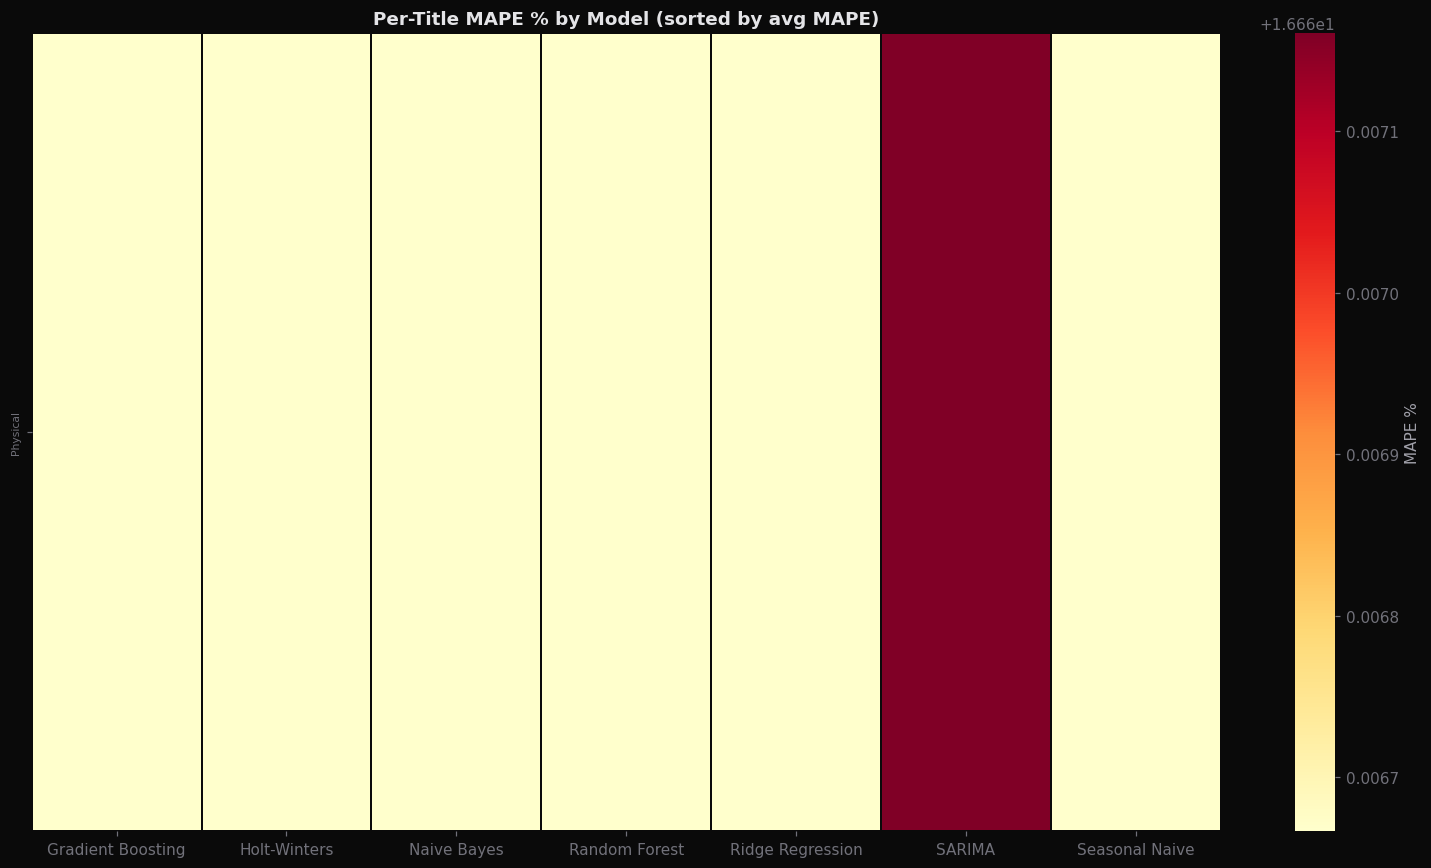

In [28]:
title_mape = (
    bt.groupby(['model','category'])['ape']
    .mean().reset_index()
)
title_mape['Label'] = title_mape['model'].map(MODEL_LABELS)
title_mape['MAPE %'] = title_mape['ape'] * 100

pivot_title = title_mape.pivot_table(index='category', columns='Label', values='MAPE %')
pivot_title = pivot_title.loc[pivot_title.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(14, max(8, len(pivot_title)*0.35)))
sns.heatmap(pivot_title, cmap='YlOrRd', ax=ax, cbar_kws={'label':'MAPE %'},
            linewidths=0.3, linecolor='#0A0A0A',
            yticklabels=[t[:45] for t in pivot_title.index])
ax.set_title('Per-Title MAPE % by Model (sorted by avg MAPE)', fontweight='bold', fontsize=12)
ax.set_xlabel(''); ax.set_ylabel('')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=7)
plt.tight_layout()
plt.show()

## 13 · Final Summary Table

In [29]:
print('='*80)
print('FINAL MODEL EVALUATION SUMMARY')
print(f'Dataset: Seattle Public Library · {n_titles} titles · {n_months} months ({date_range})')
print(f'Backtest: {BACKTEST_MONTHS} rolling months | {len(bt):,} evaluation data points')
print('='*80)
print(summary_display.to_string())
print('='*80)
print('\nMetric definitions:')
print('  MAE       – Mean Absolute Error (in checkout units)')
print('  RMSE      – Root Mean Squared Error (penalises large errors more)')
print('  MAPE %    – Mean Absolute Percentage Error (scale-independent)')
print('  MdAPE %   – Median APE (robust to outliers)')
print('  Bias      – Mean signed error (positive = over-predicts)')
print('  R²        – Coefficient of determination (1 = perfect fit)')
print('  Corr      – Pearson correlation between predicted and actual')
print('  Hit≤20%   – % of predictions within 20% of actual value')
print('  Hit≤50%   – % of predictions within 50% of actual value')
print(f'\n🏆 Best overall: {summary["MAPE_pct"].idxmin()}')

FINAL MODEL EVALUATION SUMMARY
Dataset: Seattle Public Library · 1 titles · 96 months (Oct 2016 – Sep 2024)
Backtest: 6 rolling months | 42 evaluation data points
                        MAE      RMSE     MAPE %       MdAPE %      Bias   R²      Corr    Hit≤20%    Hit≤50%  N
Model                                                                                                           
Seasonal Naive     1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Holt-Winters       1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Ridge Regression   1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Naive Bayes        1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Random Forest      1.166667  2.857738  16.666667  0.000000e+00 -1.166667 -0.2       NaN  83.333333  83.333333  6
Gradient Boosting  1.166667  2.857738  16.6666